# Si：FC2–FC5 联合拟合与热导率

`FitSystem` 是"多阶联合"的拟合接口：一套训练结构同时求解 FC2 到 FC5 的全部
参数列。本教程在硅上做四阶联合拟合，并覆盖两个重要主题：

- **壳截断语义**：截断半径按"第 $n$ 壳与第 $n{+}1$ 壳的中点"取值，对应远程 SI
  的负壳语义 $\{2:-7,\ 3:-6,\ 4:-3,\ 5:-2\}$ 的解析值；`EstimateCutoff`
  工具可以随时查询壳距；
- **可辨识性验证**：拟合前对每个阶检查折叠秩 `rank_info(order).require_full()`，
  确保参数列满秩、方程组可解。

训练集 `train.xyz` 从原始 150 帧中以固定随机种子抽取并保留 100 帧，顺序不变。拟合完成后导出
FC2/FC3 HDF5、画声子谱、用 phono3py RTA 算 300–900 K 热导率。

In [1]:
from pathlib import Path
import tempfile
import warnings

import matplotlib.pyplot as plt
import numpy as np
from ase.io import iread, read
from phonopy.structure.cells import PrimitiveMatrixAutoDefaultWarning

import mlfcs
from mlfcs import ClusterMap, ClusterSpace, FitSystem
from mlfcs.tools import EstimateCutoff

# phonopy v4 对 primitive_matrix="auto" 的默认值变更提示与本教程无关。
warnings.filterwarnings("ignore", category=PrimitiveMatrixAutoDefaultWarning)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11

SCRATCH = Path(tempfile.mkdtemp(prefix="mlfcs-si-fitting-"))
DATA = Path("data") / "si"
# 正的绝对截断(Å)，对应远程负壳语义 {2: -7, 3: -6, 4: -3, 5: -2} 的解析值；
# 壳距可用 EstimateCutoff.get(n) 查询（第 n/n+1 壳中点）。
CUTOFFS = {2: 7.418817376, 3: 6.900754996, 4: 5.001443818, 5: 4.200588768}
MAX_BODY_ORDERS = {2: 2, 3: 3, 4: 4, 5: 3}
primitive = read(DATA / "POSCAR")
print(f"mlfcs {mlfcs.__version__}")

mlfcs 4.6.0


## 壳截断查询

`EstimateCutoff` 用近邻壳层的中点作为推荐截断：截断落在壳隙里，既包含整个
第 $n$ 壳、又不会把下一壳"切一半"。远程 SI 的**负壳语义** $\{2:-7,\ 3:-6,\
4:-3,\ 5:-2\}$ 表示：FC$n$ 的截断取第 $|-k|$ 壳的中点。对比下面查出的值与
`CUTOFFS`——它们一一对应（这组截断正是这么来的）。

In [2]:
adviser = EstimateCutoff(primitive)
SHELL_SEMANTICS = {2: -7, 3: -6, 4: -3, 5: -2}
for order, shell in SHELL_SEMANTICS.items():
    print(f"FC{order}: shell {shell} midpoint {adviser.get(-shell):.9f} Å, "
          f"SI value {CUTOFFS[order]:.9f} Å")

FC2: shell -7 midpoint 7.418817376 Å, SI value 7.418817376 Å
FC3: shell -6 midpoint 6.900754996 Å, SI value 6.900754996 Å
FC4: shell -3 midpoint 5.001443818 Å, SI value 5.001443818 Å
FC5: shell -2 midpoint 4.200588768 Å, SI value 4.200588768 Å


## 模型、映射与秩检查

原胞与 $4\times4\times4$、128 原子参考超胞取自随数据入库的 `POSCAR`/`SPOSCAR`
（phonopy 生成）。超胞的**原子顺序与训练集 `train.xyz` 一致**。
`ForceDataset` 按输入顺序提取位移与力，不做原子匹配或重排；调用者需要保证顺序正确。
`ClusterMap` 从超胞原子推断超胞矩阵；`rank_info(order)` 返回该阶的折叠秩信息，
`require_full()` 在不满秩时直接抛错——把可辨识性问题拦在拟合之前。

In [3]:
supercell = read(DATA / "SPOSCAR")
space = ClusterSpace(primitive, cutoffs=CUTOFFS, max_body_orders=MAX_BODY_ORDERS)
mapping = ClusterMap(space, supercell)
for order in space.orders:
    rank = mapping.rank_info(order)
    rank.require_full()
    block = space.block(order)
    print(f"FC{order}: orbits={block.orbits.stop - block.orbits.start}, "
          f"parameters={block.parameters.stop - block.parameters.start}, rank ok")

2026-10-07 20:44:45 INFO mlfcs.cluster_space.construction: Cluster-space construction started: primitive_atoms=2 orders=(2, 3, 4, 5) symprec=1e-05


2026-10-07 20:44:45 INFO mlfcs.cluster_space.construction: Primitive symmetry ready: operations=48 symbol=Fd-3m


2026-10-07 20:44:45 INFO mlfcs.cluster_space.construction: Order construction started: order=2 cutoff_angstrom=7.418817376 max_body_order=2


2026-10-07 20:44:45 INFO mlfcs.cluster_space.construction: Candidates ready: order=2 candidates=174


2026-10-07 20:44:45 INFO mlfcs.cluster_space.construction: Order complete: order=2 orbits=9 parameters=28 elapsed_s=0.22


...

FC3: orbits=32, parameters=471, rank ok
2026-10-07 20:44:51 INFO mlfcs.mapping.cluster_map: Folded rank started: order=4


2026-10-07 20:44:51 INFO mlfcs.mapping.cluster_map: Folded rank complete: parameters=831 rank=831 nullity=0 aliases=0 elapsed_s=0.02


FC4: orbits=29, parameters=831, rank ok
2026-10-07 20:44:51 INFO mlfcs.mapping.cluster_map: Folded rank started: order=5


2026-10-07 20:44:51 INFO mlfcs.mapping.cluster_map: Folded rank complete: parameters=441 rank=441 nullity=0 aliases=0 elapsed_s=0.01


FC5: orbits=13, parameters=441, rank ok


## 联合求解与路线比较

100 帧训练结构通过 `ForceDataset` 收集为数组。首先以 raw 表示保存物理力方程，
并用列缩放后的直接 SVD 最小二乘求解；随后由同一组方程构造正规方程并用 MINRES
求解。比较只计求解阶段的墙钟时间和进程 RSS 增量，不把方程构造时间混入求解计时。
训练误差统一在原始力方程上计算。

In [4]:
from mlfcs.dataset import ForceDataset
from time import perf_counter
from threading import Event, Thread
import tracemalloc

try:
    import psutil
except ImportError:
    psutil = None


def measure_solve(label, fit_system):
    """Measure solve time and sampled RSS growth for one prepared fit system."""
    process = psutil.Process() if psutil is not None else None
    baseline = process.memory_info().rss if process is not None else None
    peak = [baseline]
    stop = Event()

    def sample_memory():
        """Track the process resident set while the solver is active."""
        while not stop.wait(0.01):
            peak[0] = max(peak[0], process.memory_info().rss)

    monitor = Thread(target=sample_memory, daemon=True) if process is not None else None
    if monitor is not None:
        monitor.start()
    tracemalloc.start()
    started = perf_counter()
    result = fit_system.solve()
    elapsed = perf_counter() - started
    _, traced_peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    if monitor is not None:
        peak[0] = max(peak[0], process.memory_info().rss)
        stop.set()
        monitor.join()
        extra_mib = (peak[0] - baseline) / 2**20
    else:
        extra_mib = float("nan")
    print(f"{label}: {elapsed:.2f} s, sampled additional RSS={extra_mib:.1f} MiB, "
          f"traced temporary peak={traced_peak / 2**20:.1f} MiB")
    return result, elapsed, extra_mib, traced_peak / 2**20


dataset = ForceDataset(mapping, iread(DATA / "train.xyz", index=":"))
system = FitSystem(dataset, representation="raw")
normal_system = system.to_normal()
print(f"frames={system.n_structures}, equations={system.n_equations}, "
      f"parameters={system.n_parameters}")
print(f"raw stored equations={system.design_matrix.nbytes + system.forces.nbytes:,} bytes; "
      f"normal stored equations={normal_system.normal_matrix.nbytes + normal_system.normal_rhs.nbytes:,} bytes")
model, direct_seconds, direct_extra_mib, direct_traced_mib = measure_solve("raw direct least squares", system)
normal_model, normal_seconds, normal_extra_mib, normal_traced_mib = measure_solve("normal equations / MINRES", normal_system)
print(f"relative force error: direct={system.relative_error(model.parameters()):.6%}, "
      f"normal={system.relative_error(normal_model.parameters()):.6%}")
parameter_difference = np.linalg.norm(model.parameters() - normal_model.parameters())
parameter_scale = max(np.linalg.norm(model.parameters()), np.finfo(float).tiny)
print(f"relative parameter difference={parameter_difference / parameter_scale:.6e}")


2026-10-07 20:44:52 INFO mlfcs.fitting.system: Fit-system construction started: representation=raw supercell_atoms=128 orders=(2, 3, 4, 5) parameters=1771 equations_per_structure=384


2026-10-07 20:44:52 INFO mlfcs.fitting.design: Force-design compilation started: supercell_atoms=128 orders=(2, 3, 4, 5) parameters=1771


2026-10-07 20:44:52 INFO mlfcs.mapping.cluster_map: Folded rank started: order=all


2026-10-07 20:44:52 INFO mlfcs.mapping.cluster_map: Folded rank complete: parameters=1771 rank=1771 nullity=0 aliases=0 elapsed_s=0.10


2026-10-07 20:45:23 INFO mlfcs.fitting.design: Force-design order ready: order=2 images=174 basis_bytes=49104


...

raw direct least squares: 11.08 s, sampled additional RSS=521.3 MiB, traced temporary peak=519.5 MiB
2026-10-07 20:56:40 INFO mlfcs.fitting.system: Fit solve started: representation=normal structures=100 equations=38400 parameters=1771 orders=(2, 3, 4, 5)


2026-10-07 20:56:40 INFO mlfcs.fitting.solve: Solver started: algorithm=MINRES normalization=inverse_column_norm rtol=1e-08 maxiter=1000


2026-10-07 20:56:41 INFO mlfcs.fitting.solve: Solver finished: algorithm=MINRES iterations=275 stop_code=0 physical_normal_residual=6.4269563920e-03


2026-10-07 20:56:41 INFO mlfcs.fitting.system: Fit complete: training_force_rmse=0.0251497522465 eV/angstrom training_relative_force_error=0.029245849 elapsed_s=0.63


normal equations / MINRES: 0.64 s, sampled additional RSS=0.0 MiB, traced temporary peak=48.0 MiB
relative force error: direct=2.924518%, normal=2.924585%
relative parameter difference=3.817160e-02


In [5]:
projection = model.enforce_asr()
fitted = projection.force_constants
parameters = fitted.parameters()
print(f"relative force error after ASR: {system.relative_error(parameters):.6%}")
for report in projection.reports:
    print(
        f"FC{report.order} ASR: relative residual "
        f"{report.relative_before:.3e} -> {report.relative_after:.3e}"
    )

2026-10-07 20:56:41 INFO mlfcs.force_constants.asr: ASR projection started: orders=(2, 3, 4, 5) rtol=1e-10


2026-10-07 20:56:41 INFO mlfcs.force_constants.asr: ASR order complete: order=2 equations=18 iterations=1 relative_before=0.000469653 relative_after=7.93884e-18 correction_norm=0.0199077


2026-10-07 20:56:41 INFO mlfcs.force_constants.asr: ASR order complete: order=3 equations=3834 iterations=17 relative_before=8.08579e-05 relative_after=1.09317e-15 correction_norm=0.0284079


2026-10-07 20:56:44 INFO mlfcs.force_constants.asr: ASR order complete: order=4 equations=68202 iterations=36 relative_before=0.00203641 relative_after=2.5793e-13 correction_norm=0.637512


2026-10-07 20:56:54 INFO mlfcs.force_constants.asr: ASR order complete: order=5 equations=299862 iterations=74 relative_before=0.00320928 relative_after=6.00311e-13 correction_norm=8.38895


2026-10-07 20:56:54 INFO mlfcs.force_constants.asr: ASR projection complete: orders=(2, 3, 4, 5) elapsed_s=13.11


relative force error after ASR: 3.036986%
FC2 ASR: relative residual 4.697e-04 -> 7.939e-18
FC3 ASR: relative residual 8.086e-05 -> 1.093e-15
FC4 ASR: relative residual 2.036e-03 -> 2.579e-13
FC5 ASR: relative residual 3.209e-03 -> 6.003e-13


## 导出与声子谱

FC2/FC3 导出为下游输运使用的 HDF5 文件。声子谱直接通过
`Harmonic(fitted).run_band_path(npoints=200)` 计算；它自动生成 ASE 路径，并返回绘图元数据。

In [6]:
fc2_path = SCRATCH / "fc2-phonopy.hdf5"
fc3_path = SCRATCH / "fc3-phono3py.hdf5"
fitted.write(fc2_path, mapping, format="phonopy", storage="hdf5", order=2)
fitted.write(fc3_path, mapping, format="phono3py", storage="hdf5", order=3)
print(f"fc2 -> {fc2_path}")
print(f"fc3 -> {fc3_path}")

2026-10-07 20:56:54 INFO mlfcs.force_constants.formats: Export started: path=/tmp/mlfcs-si-fitting-b14ppo14/fc2-phonopy.hdf5 format=phonopy order=2 storage=hdf5 threshold=1e-08


2026-10-07 20:56:54 INFO mlfcs.force_constants.formats: Export complete: path=/tmp/mlfcs-si-fitting-b14ppo14/fc2-phonopy.hdf5 format=phonopy order=2 elapsed_s=0.35


2026-10-07 20:56:54 INFO mlfcs.force_constants.formats: Export started: path=/tmp/mlfcs-si-fitting-b14ppo14/fc3-phono3py.hdf5 format=phono3py order=3 storage=hdf5 threshold=1e-08


2026-10-07 20:57:05 INFO mlfcs.force_constants.formats: Export complete: path=/tmp/mlfcs-si-fitting-b14ppo14/fc3-phono3py.hdf5 format=phono3py order=3 elapsed_s=11.02


fc2 -> /tmp/mlfcs-si-fitting-b14ppo14/fc2-phonopy.hdf5
fc3 -> /tmp/mlfcs-si-fitting-b14ppo14/fc3-phono3py.hdf5


2026-10-07 20:57:05 INFO mlfcs.phonon.harmonic: Harmonic preparation started: primitive_atoms=2


2026-10-07 20:57:05 INFO mlfcs.phonon.harmonic: Harmonic preparation complete: terms=174 elapsed_s=0.01


2026-10-07 20:57:05 INFO mlfcs.phonon.harmonic: Harmonic frequencies: qpoints=200 modes_per_q=6 imaginary_modes=4 range=[-2.1813129e-07, 15.128074] THz elapsed=0.00 s


path: GXWKGLUWLK,UX, qpoints: 200


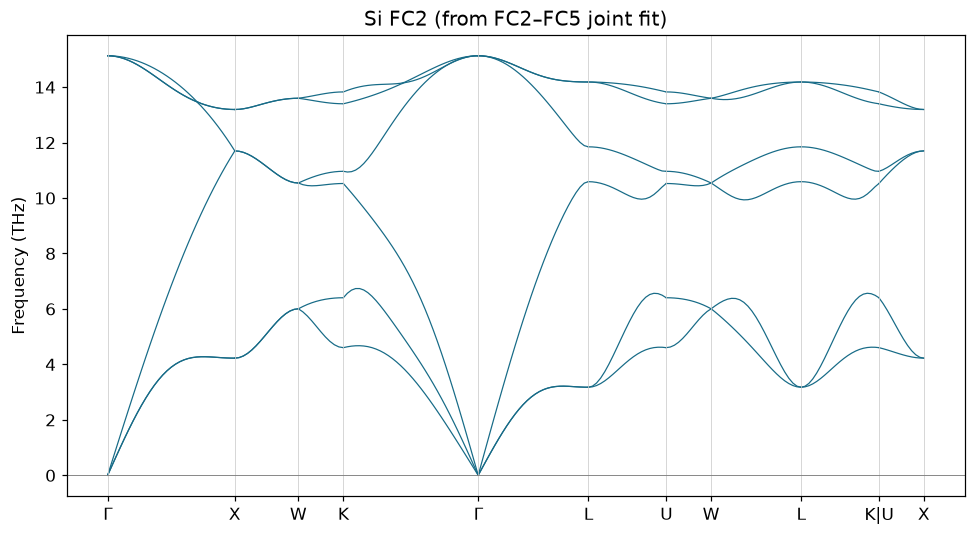

In [7]:
from mlfcs.phonon import Harmonic
from phono3py.file_IO import read_fc2_from_hdf5
from phonopy.structure.atoms import PhonopyAtoms

# The exported FC2/FC3 files and this atom order are used by phono3py below.
unitcell = PhonopyAtoms(
    symbols=supercell.get_chemical_symbols(),
    cell=supercell.cell.array,
    scaled_positions=supercell.get_scaled_positions(),
    masses=supercell.get_masses(),
)
bands = Harmonic(fitted).run_band_path(npoints=200)
print(f"path: {bands.path}, qpoints: {len(bands.qpoints)}")

fig, axis = plt.subplots(figsize=(9, 5))
for segment in bands.segments:
    axis.plot(bands.distances[segment], bands.frequencies_thz[segment], color="#176b87", lw=0.8)
axis.set_xticks(bands.tick_positions, bands.tick_labels)
for tick in bands.tick_positions:
    axis.axvline(tick, color="0.8", lw=0.5)
axis.axhline(0.0, color="0.5", lw=0.6)
axis.set_ylabel("Frequency (THz)")
axis.set_title("Si FC2 (from FC2–FC5 joint fit)")
fig.tight_layout()
plt.show()

## 热导率（phono3py RTA，300–900 K）

FC5 的高阶力常数不直接进入 RTA 输运（phono3py 消费 FC2/FC3），但联合拟合把
低阶参数约束在更自洽的解上——这是多阶联合拟合对输运性质的意义。

In [8]:
from phono3py import Phono3py
from phono3py.file_IO import read_fc3_from_hdf5

MESH = (10, 10, 10)
TEMPERATURES = tuple(range(300, 901, 100))

ph3 = Phono3py(unitcell, np.eye(3, dtype=int), primitive_matrix="auto", log_level=0)
p2s_map = np.asarray(ph3.phonon_primitive.p2s_map, dtype=int)
ph3.fc2 = read_fc2_from_hdf5(str(fc2_path))[p2s_map]
ph3.fc3 = read_fc3_from_hdf5(str(fc3_path))[p2s_map]
ph3.mesh_numbers = MESH
ph3.init_phph_interaction()
ph3.run_thermal_conductivity(
    temperatures=TEMPERATURES,
    is_isotope=True,
    write_kappa=False,
    log_level=0,
)
kappa = np.asarray(ph3.thermal_conductivity.kappa).reshape(-1, 6)
print(f"{'T (K)':>8} {'kappa_xx':>10} {'kappa_yy':>10} {'kappa_zz':>10}  W/(m·K)")
for temperature, values in zip(TEMPERATURES, kappa):
    print(f"{temperature:>8} {values[0]:>10.3f} {values[1]:>10.3f} {values[2]:>10.3f}")

   T (K)   kappa_xx   kappa_yy   kappa_zz  W/(m·K)
     300    114.930    114.930    114.930
     400     83.401     83.401     83.401
     500     65.891     65.891     65.891
     600     54.623     54.623     54.623
     700     46.716     46.716     46.716
     800     40.842     40.842     40.842
     900     36.298     36.298     36.298


## 小结

- 多阶联合拟合的方程组一次成型，`rank_info(...).require_full()` 把可辨识性
  检查前置到拟合之前；
- `EstimateCutoff` 让"壳语义截断"可查询、可复现，不再依赖脚本里的魔法数；
- 联合拟合 + ASR 投影 + 标准格式导出，直接对接 phonopy/phono3py 输运流水线。